In [26]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict 

## Cài đặt và Làm quen môi trường

#### Môi trường CartPole-v1

In [27]:
env_cp = gym.make("CartPole-v1")
obs, info = env_cp.reset()

print("CartPole-v1")
print("observation_space:", env_cp.observation_space)
print("action_space:", env_cp.action_space)
print("Quan sát ban đầu                       :", obs)

# Thử 1 bước để xem reward
obs2, reward, terminated, truncated, info2 = env_cp.step(0)
print("Reward sau 1 bước                      :", reward)
env_cp.close()

CartPole-v1
observation_space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action_space: Discrete(2)
Quan sát ban đầu                       : [ 0.04643509 -0.0260072   0.04225414  0.03395888]
Reward sau 1 bước                      : 1.0


**CartPole-v1:**

- **Observation có bao nhiêu chiều?** → 4 chiều
- **State space là liên tục hay rời rạc?** → Liên tục
- **Action space là rời rạc hay liên tục?** → Rời rạc
- **Reward được tính như thế nào?** → +1 cho mỗi bước thời gian mà cột chưa đổ
- **Khi nào episode kết thúc?** → Góc cột vượt quá mức, Xe ra ngoài biên , hoặc đạt số bước.

#### Môi trường MountainCar-v0

In [28]:
env_mc = gym.make("MountainCar-v0")
obs_mc, info_mc = env_mc.reset()

print("MountainCar-v0")
print("observation_space:", env_mc.observation_space)
print("action_space:", env_mc.action_space)
print("Quan sát ban đầu                       :", obs_mc)

obs_mc2, reward_mc, term_mc, trunc_mc, info_mc2 = env_mc.step(0)
print("Reward sau 1 bước                      :", reward_mc)
env_mc.close()

MountainCar-v0
observation_space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
action_space: Discrete(3)
Quan sát ban đầu                       : [-0.5925943  0.       ]
Reward sau 1 bước                      : -1.0


**MountainCar-v0:**

- **Observation có bao nhiêu chiều?** → 2 chiều: vị trí xe (position) và vận tốc xe (velocity).
- **State space là liên tục hay rời rạc?** → Liên tục.
- **Action space là rời rạc hay liên tục?** → Rời rạc
- **Reward được tính như thế nào?** → -1 cho mỗi bước thời gian, khuyến khích agent đến đích nhanh nhất có thể.
- **Khi nào episode kết thúc?** → Xe đạt đến cờ, hoặc đạt tới số bước tối đa.


## Random Agent & Quy trình RL

In [29]:
def chay_random_agent(ten_moi_truong, so_episode=120, seed=42):
    env = gym.make(ten_moi_truong)
    ds_reward = []
    
    for ep in range(so_episode):
        obs, _ = env.reset(seed=seed + ep)
        tong_reward = 0
        done = False
        
        while not done:
            hanh_dong = env.action_space.sample()  # chọn hành động ngẫu nhiên
            obs, reward, terminated, truncated, _ = env.step(hanh_dong)
            tong_reward += reward
            done = terminated or truncated
        
        ds_reward.append(tong_reward)
    
    env.close()
    return ds_reward

# Chạy cho cả hai môi trường
print("Đang chạy Random Agent trên CartPole-v1...")
reward_cartpole = chay_random_agent("CartPole-v1", so_episode=120)

print("Đang chạy Random Agent trên MountainCar-v0...")
reward_mountaincar = chay_random_agent("MountainCar-v0", so_episode=120)

print(f"CartPole   - Reward TB: {np.mean(reward_cartpole):.2f}")
print(f"MountainCar - Reward TB: {np.mean(reward_mountaincar):.2f}")

Đang chạy Random Agent trên CartPole-v1...
Đang chạy Random Agent trên MountainCar-v0...
CartPole   - Reward TB: 22.18
MountainCar - Reward TB: -200.00


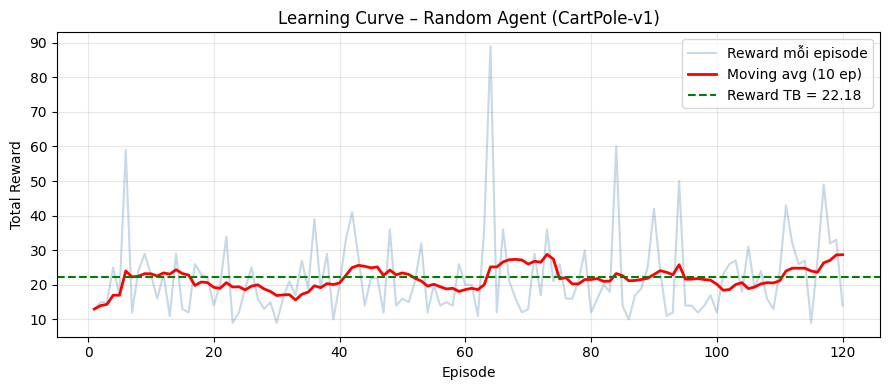

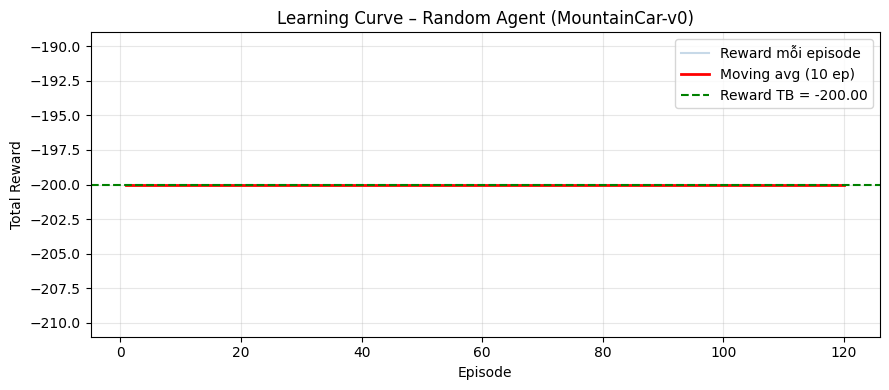

In [30]:
# Vẽ Learning Curve
def ve_learning_curve(ds_reward, ten_moi_truong, cua_so=10):
    episodes = np.arange(1, len(ds_reward) + 1)
    # tính moving average để đường cong mượt hơn
    moving_avg = [np.mean(ds_reward[max(0, i-cua_so):i+1]) for i in range(len(ds_reward))]
    
    plt.figure(figsize=(9, 4))
    plt.plot(episodes, ds_reward, alpha=0.3, color='steelblue', label='Reward mỗi episode')
    plt.plot(episodes, moving_avg, color='red', linewidth=2, label=f'Moving avg ({cua_so} ep)')
    plt.axhline(np.mean(ds_reward), color='green', linestyle='--', linewidth=1.5,
                label=f'Reward TB = {np.mean(ds_reward):.2f}')
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title(f"Learning Curve – Random Agent ({ten_moi_truong})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

ve_learning_curve(reward_cartpole, "CartPole-v1")
ve_learning_curve(reward_mountaincar, "MountainCar-v0")

- **Reward trung bình của random agent là bao nhiêu?**  
  → CartPole: khoảng 20–25 bước. MountainCar: luôn là -200.

- **Có xu hướng tăng theo thời gian không?**  
  → Không có xu hướng tăng. Reward dao động ngẫu nhiên quanh giá trị trung bình, không có chiều hướng cải thiện.

- **Random agent có hội tụ không?**  
  → Không hội tụ. Vì agent chọn hành động ngẫu nhiên hoàn toàn, không có cơ chế học, không cập nhật policy theo kinh nghiệm.

- **Vì sao cần một policy học được?**  
  → Để cải thiện hiệu suất theo thời gian và nó sẽ đưa ra trạng thái tốt nhất cho mỗi hành động dựa trên kinh nghiệm Còn random agent thì khôg có khả năng, nó kà sự ngẫu nhiên nên không học được kinh nghiệm gì để đưa ra hành động dẫn đến trạng thái tốt hơn.

##  MDP & Dynamic Programming cho CartPole

### 4.1 Mô hình hóa CartPole dưới dạng MDP

**Các thành phần của MDP:**

**Vì sao CartPole không phải MDP hữu hạn?**  
→ Vì không gian trạng thái S là kiểu `Box` (liên tục), mỗi trong 4 chiều nhận giá trị thực trong khoảng liên tục → số lượng trạng thái là vô hạn, không thể liệt kê hết được.

**Vì sao không thể áp dụng trực tiếp Dynamic Programming?**  
→ DP yêu cầu không gian trạng thái hữu hạn và liệt kê được, (2) biết ma trận xác suất chuyển P(s'|s,a). CartPole vi phạm cả hai: state liên tục và môi trường là "hộp đen" (black-box simulator, không biết P).

### 4.2 State Discretization

In [31]:
SO_BINS = 10
BIEN_DUOI = np.array([-2.4, -3.0, -0.2095, -3.0])  # giới hạn nhỏ nhất
BIEN_TREN = np.array([ 2.4,  3.0,  0.2095,  3.0])  # giới hạn lớn nhất

# np.linspace tạo ra các điểm chia đều trong khoảng

BIN_CANH = [
    np.linspace(BIEN_DUOI[i], BIEN_TREN[i], SO_BINS - 1)
    for i in range(4)
]

def roi_rac_hoa_trang_thai(obs):

    # giới hạn giá trị observation trong khoảng cho phép
    obs_clip = np.clip(obs, BIEN_DUOI, BIEN_TREN)

    # xác định mỗi giá trị thuộc bin nào
    chi_so = tuple(
        np.digitize(obs_clip[i], BIN_CANH[i])
        for i in range(4)
    )
    return chi_so


env_test = gym.make("CartPole-v1")
obs_test, _ = env_test.reset(seed=0)

# Chuyển observation liên tục → state rời rạc
trang_thai_roi_rac = roi_rac_hoa_trang_thai(obs_test)

# In kết quả
print(f"Observation liên tục : {obs_test}")
print(f"Trạng thái rời rạc   : {trang_thai_roi_rac}")
print(f"Tổng số trạng thái   : {SO_BINS}^4 = {SO_BINS**4:,}")

env_test.close()

Observation liên tục : [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
Trạng thái rời rạc   : (np.int64(5), np.int64(4), np.int64(4), np.int64(4))
Tổng số trạng thái   : 10^4 = 10,000


- **Nếu tăng số bins thì điều gì xảy ra?**  
  → Thì trạng thái không gian sẽ tăng lên theo cấp luỹ thừa. Đồng thời độ chính xác cũng tăng theo.Nhưng nó sẽ thời gian và bộ nhớ tinh toán.

- **Trade-off giữa độ chính xác và chi phí tính toán?**  
  → Bins nhiều hơn = xấp xỉ tốt hơn nhưng: cần nhiều mẫu hơn để ước lượng P̂ chính xác ở mỗi (s,a), bảng V/Q có kích thước khổng lồ, DP chạy chậm hơn nhiều. Đây là "curse of dimensionality" – phải chọn bins vừa đủ.

### 4.3 Xây dựng Model-Based MDP từ Samples

In [32]:
def thu_thap_transitions(so_episode=500, seed=0):
    """Thu thập (s, a, r, s') bằng random policy trên CartPole."""
    env = gym.make("CartPole-v1")
    
    # dem_chuyen_doi[s][a][s'] = số lần gặp
    dem_chuyen_doi = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    # tong_reward_sa[s][a] = tổng reward
    tong_reward_sa = defaultdict(lambda: defaultdict(float))
    # dem_sa[s][a] = số lần gặp (s,a)
    dem_sa = defaultdict(lambda: defaultdict(int))
    
    for ep in range(so_episode):
        obs, _ = env.reset(seed=seed + ep)
        s = roi_rac_hoa_trang_thai(obs)
        done = False
        
        while not done:
            a = env.action_space.sample()
            obs_moi, r, terminated, truncated, _ = env.step(a)
            s_moi = roi_rac_hoa_trang_thai(obs_moi)
            
            dem_chuyen_doi[s][a][s_moi] += 1
            tong_reward_sa[s][a] += r
            dem_sa[s][a] += 1
            
            s = s_moi
            done = terminated or truncated
    
    env.close()
    return dem_chuyen_doi, tong_reward_sa, dem_sa

print("Đang thu thập transitions (500 episodes)...")
dem_chuyen_doi, tong_reward_sa, dem_sa = thu_thap_transitions(so_episode=500)

tong_cap_sa = sum(dem_sa[s][a] for s in dem_sa for a in dem_sa[s])
so_trang_thai_gap = len(dem_sa)
print(f"Số cặp (s,a) thu thập được : {tong_cap_sa:,}")
print(f"Số trạng thái khác nhau gặp: {so_trang_thai_gap:,} / {SO_BINS**4:,}")

Đang thu thập transitions (500 episodes)...
Số cặp (s,a) thu thập được : 11,455
Số trạng thái khác nhau gặp: 212 / 10,000


In [33]:
def tinh_xac_suat_chuyen(dem_chuyen_doi, dem_sa):
    """Ước lượng P̂(s'|s,a) và R̂(s,a) từ dữ liệu thu thập."""
    P_uoc_luong = defaultdict(lambda: defaultdict(dict))
    R_uoc_luong = defaultdict(lambda: defaultdict(float))
    
    for s in dem_chuyen_doi:
        for a in dem_chuyen_doi[s]:
            tong = dem_sa[s][a]
            for s_moi, dem in dem_chuyen_doi[s][a].items():
                P_uoc_luong[s][a][s_moi] = dem / tong
            R_uoc_luong[s][a] = tong_reward_sa[s][a] / tong
    
    return P_uoc_luong, R_uoc_luong

P_hat, R_hat = tinh_xac_suat_chuyen(dem_chuyen_doi, dem_sa)

# Kiểm tra một cặp (s,a) mẫu
s_mau = list(P_hat.keys())[0]
print(f"Ví dụ trạng thái s = {s_mau}")
print(f"  Số lần gặp (s,0): {dem_sa[s_mau][0]}, (s,1): {dem_sa[s_mau][1]}")
print(f"  R̂(s,0)={R_hat[s_mau][0]:.3f}, R̂(s,1)={R_hat[s_mau][1]:.3f}")

Ví dụ trạng thái s = (np.int64(5), np.int64(4), np.int64(4), np.int64(4))
  Số lần gặp (s,0): 52, (s,1): 44
  R̂(s,0)=1.000, R̂(s,1)=1.000


- **Cần bao nhiêu samples để ước lượng tốt?**  
  → Theo quy tắc thực nghiệm cần ít nhất 30–50 lượt thăm mỗi cặp (s,a) để P̂ đủ tin cậy. Với 10,000 trạng thái × 2 hành động = 20,000 cặp (s,a), cần khoảng 600,000–1,000,000 transitions. Tuy nhiên random policy không thể thăm đủ nhiều trạng thái "khó" (xa điểm ban đầu), nên trong thực tế ước lượng bị thiên lệch.

- **Model ước lượng có chính xác không?**  
  → Chưa chính xác hoàn toàn vì: Random policy không khai thác đủ mọi trạng thái (exploration không đồng đều), Số samples còn hạn chế so với không gian trạng thái rời rạc 10,000 states, Rời rạc hóa đã làm mất thông tin về state liên tục gốc.

### 4.4 Áp dụng Dynamic Programming

In [34]:
GAMMA = 0.99      # hệ số chiết khấu
THETA = 1e-4      # ngưỡng hội tụ
SO_HANH_DONG = 2  # {0, 1}

def value_iteration(P_hat, R_hat, dem_sa, gamma=GAMMA, theta=THETA):
    V = defaultdict(float)
    so_vong_lap = 0
    
    while True:
        delta = 0
        for s in dem_sa:
            v_cu = V[s]
            gia_tri_hanh_dong = []
            
            for a in range(SO_HANH_DONG):
                if dem_sa[s][a] == 0:
                    gia_tri_hanh_dong.append(0.0)
                    continue
                
                gia_tri_a = R_hat[s][a]
                if s in P_hat and a in P_hat[s]:
                    for s_moi, xac_suat in P_hat[s][a].items():
                        gia_tri_a += gamma * xac_suat * V[s_moi]
                gia_tri_hanh_dong.append(gia_tri_a)
            
            V[s] = max(gia_tri_hanh_dong)
            delta = max(delta, abs(v_cu - V[s]))
        
        so_vong_lap += 1
        if delta < theta:
            break
    
    # Trích xuất policy tham lam
    policy_vi = {}
    for s in dem_sa:
        gia_tri_hanh_dong = []
        for a in range(SO_HANH_DONG):
            if dem_sa[s][a] == 0:
                gia_tri_hanh_dong.append(0.0)
                continue
            gia_tri_a = R_hat[s][a]
            if s in P_hat and a in P_hat[s]:
                for s_moi, xac_suat in P_hat[s][a].items():
                    gia_tri_a += gamma * xac_suat * V[s_moi]
            gia_tri_hanh_dong.append(gia_tri_a)
        policy_vi[s] = int(np.argmax(gia_tri_hanh_dong))
    
    return V, policy_vi, so_vong_lap

print("Đang chạy Value Iteration...")
V_vi, policy_vi, vong_lap_vi = value_iteration(P_hat, R_hat, dem_sa)
print(f"Value Iteration hội tụ sau {vong_lap_vi} vòng lặp")
print(f"Số trạng thái có policy: {len(policy_vi)}")

Đang chạy Value Iteration...
Value Iteration hội tụ sau 918 vòng lặp
Số trạng thái có policy: 212


In [35]:
def policy_iteration(P_hat, R_hat, dem_sa, gamma=GAMMA, theta=THETA):
    """Policy Iteration: Xen kẽ Policy Evaluation và Policy Improvement."""
    # Khởi tạo policy ngẫu nhiên
    policy_pi = {s: np.random.randint(SO_HANH_DONG) for s in dem_sa}
    V = defaultdict(float)
    so_vong_lap = 0
    
    while True:
        # --- Policy Evaluation ---
        while True:
            delta = 0
            for s in dem_sa:
                v_cu = V[s]
                a = policy_pi[s]
                
                if dem_sa[s][a] == 0:
                    V[s] = 0.0
                    continue
                
                gia_tri = R_hat[s][a]
                if s in P_hat and a in P_hat[s]:
                    for s_moi, xac_suat in P_hat[s][a].items():
                        gia_tri += gamma * xac_suat * V[s_moi]
                V[s] = gia_tri
                delta = max(delta, abs(v_cu - V[s]))
            
            if delta < theta:
                break
        
        # --- Policy Improvement ---
        policy_on_dinh = True
        for s in dem_sa:
            a_cu = policy_pi[s]
            gia_tri_hanh_dong = []
            
            for a in range(SO_HANH_DONG):
                if dem_sa[s][a] == 0:
                    gia_tri_hanh_dong.append(0.0)
                    continue
                gia_tri_a = R_hat[s][a]
                if s in P_hat and a in P_hat[s]:
                    for s_moi, xac_suat in P_hat[s][a].items():
                        gia_tri_a += gamma * xac_suat * V[s_moi]
                gia_tri_hanh_dong.append(gia_tri_a)
            
            policy_pi[s] = int(np.argmax(gia_tri_hanh_dong))
            if policy_pi[s] != a_cu:
                policy_on_dinh = False
        
        so_vong_lap += 1
        if policy_on_dinh:
            break
    
    return V, policy_pi, so_vong_lap

print("Đang chạy Policy Iteration...")
V_pi, policy_pi, vong_lap_pi = policy_iteration(P_hat, R_hat, dem_sa)
print(f"Policy Iteration hội tụ sau {vong_lap_pi} vòng lặp (mỗi vòng gồm Eval + Improve)")

Đang chạy Policy Iteration...
Policy Iteration hội tụ sau 26 vòng lặp (mỗi vòng gồm Eval + Improve)


**So sánh Value Iteration vs Policy Iteration:**

| Tiêu chí | Value Iteration | Policy Iteration |
|---|---|---|
| **Số vòng lặp** | Nhiều hơn | Ít hơn |
| **Chi phí mỗi vòng** | Thấp (1 lần sweep) | Cao (evaluation đến hội tụ) |
| **Tổng thời gian** | Tương đương hoặc nhanh hơn với state space nhỏ | Tốt hơn với state space lớn và policy converge nhanh |
| **Ý tưởng** | Cập nhật V trực tiếp qua Bellman optimality | Xen kẽ đánh giá policy hiện tại và cải thiện greedy |

### 4.5 Đánh giá và so sánh

In [36]:
def danh_gia_policy(policy_dict, so_episode=100, seed=100):
    env = gym.make("CartPole-v1")
    ds_reward = []
    
    for ep in range(so_episode):
        obs, _ = env.reset(seed=seed + ep)
        s = roi_rac_hoa_trang_thai(obs)
        tong_reward = 0
        done = False
        
        while not done:
            # Nếu không biết state này, chọn ngẫu nhiên
            a = policy_dict.get(s, env.action_space.sample())
            obs, r, terminated, truncated, _ = env.step(a)
            s = roi_rac_hoa_trang_thai(obs)
            tong_reward += r
            done = terminated or truncated
        
        ds_reward.append(tong_reward)
    
    env.close()
    return ds_reward

# Đánh giá 3 agent trên 100 episodes
reward_random_eval = chay_random_agent("CartPole-v1", so_episode=100, seed=100)
reward_vi_eval = danh_gia_policy(policy_vi, so_episode=100)
reward_pi_eval = danh_gia_policy(policy_pi, so_episode=100)

print(f"\nKết quả đánh giá (100 episodes):")
print(f"{'Agent':<25} {'TB Reward':>12} {'Std':>8} {'Max':>6}")
print("-" * 55)
for ten, ds in [("Random Agent", reward_random_eval),
                ("Value Iteration", reward_vi_eval),
                ("Policy Iteration", reward_pi_eval)]:
    print(f"{ten:<25} {np.mean(ds):>12.2f} {np.std(ds):>8.2f} {np.max(ds):>6.0f}")


Kết quả đánh giá (100 episodes):
Agent                        TB Reward      Std    Max
-------------------------------------------------------
Random Agent                     21.62    12.54    103
Value Iteration                   9.69     0.97     12
Policy Iteration                 11.77     2.39     27


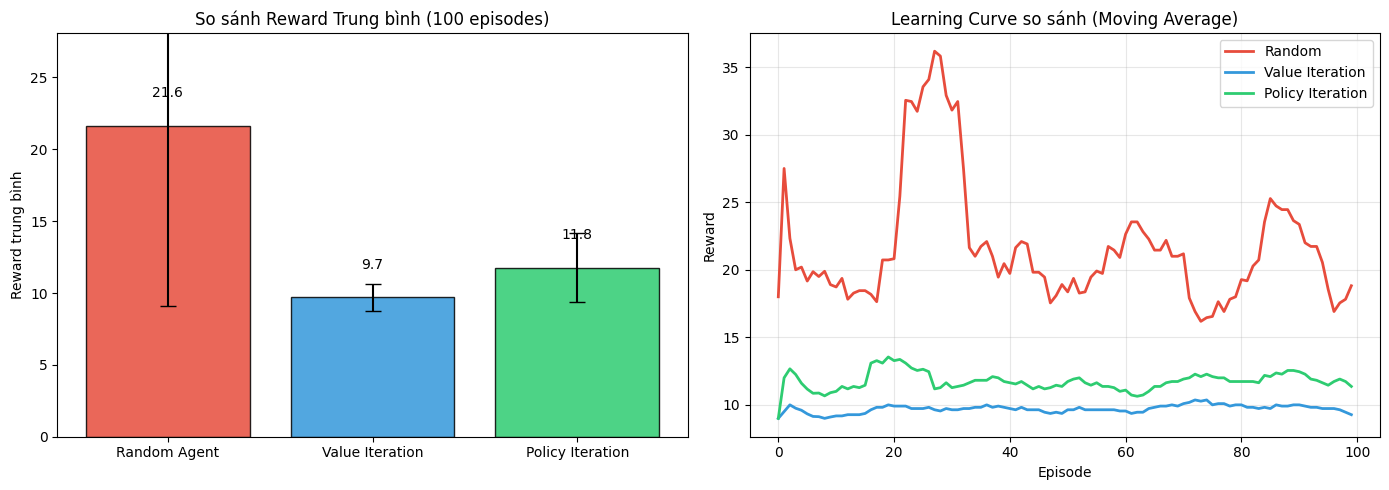

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]

# Tên các agent
agents = ["Random Agent", "Value Iteration", "Policy Iteration"]

# Tính reward trung bình
tb_rewards = [
    np.mean(reward_random_eval),
    np.mean(reward_vi_eval),
    np.mean(reward_pi_eval)
]

# Độ dao động reward
std_rewards = [
    np.std(reward_random_eval),
    np.std(reward_vi_eval),
    np.std(reward_pi_eval)
]

# Màu cho từng agent
colors = ['#e74c3c', '#3498db', '#2ecc71']

# Vẽ biểu đồ cột
bars = ax1.bar(
    agents,
    tb_rewards,
    yerr=std_rewards,     # thanh sai số
    capsize=6,
    color=colors,
    alpha=0.85,
    edgecolor='black'
)

ax1.set_title("So sánh Reward Trung bình (100 episodes)")
ax1.set_ylabel("Reward trung bình")

# Giới hạn trục Y
ax1.set_ylim(0, max(tb_rewards) * 1.3)

# Hiển thị số trên đầu cột
for bar, value in zip(bars, tb_rewards):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{value:.1f}",
        ha='center'
    )

# Biểu đồ Learning Curve
ax2 = axes[1]
cua_so = 10   # cửa sổ để tính moving average

# Danh sách agent để vẽ
ds_agent = [
    ("Random", reward_random_eval, '#e74c3c'),
    ("Value Iteration", reward_vi_eval, '#3498db'),
    ("Policy Iteration", reward_pi_eval, '#2ecc71')
]

for ten, ds_reward, color in ds_agent:

    # Tính moving average
    moving_avg = [
        np.mean(ds_reward[max(0, i-cua_so):i+1])
        for i in range(len(ds_reward))
    ]

    ax2.plot(
        moving_avg,
        label=ten,
        color=color,
        linewidth=2
    )

ax2.set_title("Learning Curve so sánh (Moving Average)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Reward")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

**Nhận xét kết quả so sánh:**

- **Reward trung bình:** DP agents (VI & PI) đạt reward cao hơn đáng kể so với Random Agent do đã học được policy hợp lý từ model ước lượng.
- **Tốc độ hội tụ:** Cả VI và PI đều ổn định ngay từ đầu, trong khi Random Agent không cải thiện qua các episode.
- **Độ ổn định:** DP agents có độ lệch chuẩn thấp hơn, cho thấy policy nhất quán và ít ngẫu nhiên hơn.

## 5: Phân tích bản chất thuật toán

**1. Dynamic Programming (DP) có cần environment model không?**  
→ **Có.** DP là phương pháp *model-based* – cần biết đầy đủ xác suất chuyển trạng thái P(s'|s,a) và hàm reward R(s,a) để tính toán


**2. Vì sao phải ước lượng transition probabilities trước khi áp dụng DP?**  
→ Vì CartPole là môi trường *black-box* – chúng ta chỉ tương tác được qua `env.step()`, không có công thức toán học nào cho P. Do đó phải dùng phương pháp *model learning*: chạy nhiều episodes với random policy, đếm tần suất chuyển trạng thái, rồi ước lượng P̂(s'|s,a) = count(s,a,s') / count(s,a). Sau đó mới áp dụng DP trên model ước lượng này.

**3. Nếu state space rất lớn (ví dụ 100,000 trạng thái) thì DP còn khả thi không?**  
→ Về lý thuyết vẫn khả thi nhưng **rất khó trong thực tế**. Với 100,000 states × 2 actions, bảng P đầy đủ có thể cần đến 20 tỷ entries (100K × 2 × 100K). Mỗi vòng lặp DP phải duyệt toàn bộ state space → rất chậm. 

**4. Vì sao DP khó áp dụng trực tiếp cho môi trường continuous?**  
→ Vì DP cần **liệt kê từng trạng thái** để cập nhật bảng V/Q, nhưng continuous state space có vô số trạng thái – không thể tạo bảng hữu hạn. Phép tính tổng Σ_s' P(s'|s,a)V(s') trở thành tích phân không giải được theo bảng tra. Giải pháp là rời rạc hóa hoặc dùng value function approximation (neural network, tile coding, ...).

**5. Ưu điểm và nhược điểm lớn nhất của model-based DP là gì?**

| | Nội dung |
|---|---|
|**Ưu điểm** | **Hiệu quả mẫu cao (sample efficient):** Sau khi học xong model, có thể lập kế hoạch (planning) nhiều lần mà không cần tương tác thêm với môi trường thực. Hội tụ đảm bảo với model chính xác. |
|**Nhược điểm** | **Sai lệch model (model bias):** Nếu P̂ không chính xác (do thiếu dữ liệu, rời rạc hóa thô, v.v.), policy học được sẽ tối ưu cho model sai chứ không phải môi trường thật – "garbage in, garbage out". Ngoài ra chi phí lưu trữ và tính toán model tăng theo bậc hai với số states.|